In [280]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np


In [281]:
import importlib
import feature_extraction
importlib.reload(feature_extraction)
from feature_extraction import extract_features

In [282]:
# Load dataset
df = pd.read_csv("dataset/phishing.csv")

# Check column names
print(df.columns)



Index(['URLs', 'Label'], dtype='object')


In [283]:
df

,URLs,Label
0,http://www.wmmayhem.com/,Benign
1,http://www.ballymenaunitedyouthacademy.com/,Benign
2,http://www.brusselsgaybars.com/,Benign
3,http://www.sportsbettingtennis.net/,Benign
4,http://www.i29.mobi/,Benign
...,...,...
38795,http://www.xz58plamx.blogspot.com/,Phishing
38796,http://www.zc64cpalz.blogspot.com/,Phishing
38797,http://www.zeynelguven.com//site/help/css/payp...,Phishing
38798,http://www.zpqmf103kd.blogspot.com/,Phishing


In [284]:
# Convert labels to numeric
df['Label'] = df['Label'].map({
    'Benign': 0,
    'Phishing': 1
})



In [285]:
df

,URLs,Label
0,http://www.wmmayhem.com/,0
1,http://www.ballymenaunitedyouthacademy.com/,0
2,http://www.brusselsgaybars.com/,0
3,http://www.sportsbettingtennis.net/,0
4,http://www.i29.mobi/,0
...,...,...
38795,http://www.xz58plamx.blogspot.com/,1
38796,http://www.zc64cpalz.blogspot.com/,1
38797,http://www.zeynelguven.com//site/help/css/payp...,1
38798,http://www.zpqmf103kd.blogspot.com/,1


In [286]:
# Remove rows with missing labels
df = df.dropna()

In [287]:
# Remove rows with exact duplicates   
df = df.drop_duplicates()



In [288]:
df

,URLs,Label
0,http://www.wmmayhem.com/,0
1,http://www.ballymenaunitedyouthacademy.com/,0
2,http://www.brusselsgaybars.com/,0
3,http://www.sportsbettingtennis.net/,0
4,http://www.i29.mobi/,0
...,...,...
38795,http://www.xz58plamx.blogspot.com/,1
38796,http://www.zc64cpalz.blogspot.com/,1
38797,http://www.zeynelguven.com//site/help/css/payp...,1
38798,http://www.zpqmf103kd.blogspot.com/,1


In [289]:
df['URLs'].shape[0]

36365

In [290]:
# Extract features
X = df['URLs'].apply(extract_features).tolist()

# Labels
y = df['Label']

18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
1

In [291]:
X

[[24,
  0,
  2,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  16,
  0.0,
  0.46153846153846156,
  3.470175521464345,
  0.5416666666666666,
  2,
  0],
 [43,
  0,
  2,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  35,
  0.0,
  0.2978723404255319,
  4.129184812590067,
  0.4418604651162791,
  2,
  0],
 [31,
  0,
  2,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  23,
  0.0,
  0.42424242424242425,
  4.0667842134731025,
  0.6129032258064516,
  2,
  0],
 [35,
  0,
  2,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  27,
  0.0,
  0.10810810810810811,
  3.6243963180004775,
  0.42857142857142855,
  2,
  0],
 [20,
  0,
  2,
  0,
  0,
  3,
  0,
  0,
  2,
  0,
  0,
  12,
  0.15384615384615385,
  0.18181818181818182,
  3.5464393446710156,
  0.65,
  2,
  0],
 [33,
  0,
  3,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  25,
  0.0,
  0.22857142857142856,
  3.914569497687415,
  0.5151515151515151,
  3,
  0],
 [46,
  0,
  4,
  0,
  0,
  4,
  0,
  0,
  0,
  0,
  0,
  20,
  0.0,
  0.13333333333333333,
  4.018794978907587,
  0.43

In [292]:
len(X[0])

18

In [293]:
y

0        0
1        0
2        0
3        0
4        0
        ..
38795    1
38796    1
38797    1
38798    1
38799    1
Name: Label, Length: 36365, dtype: int64

In [294]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)



In [295]:
# Train model
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)



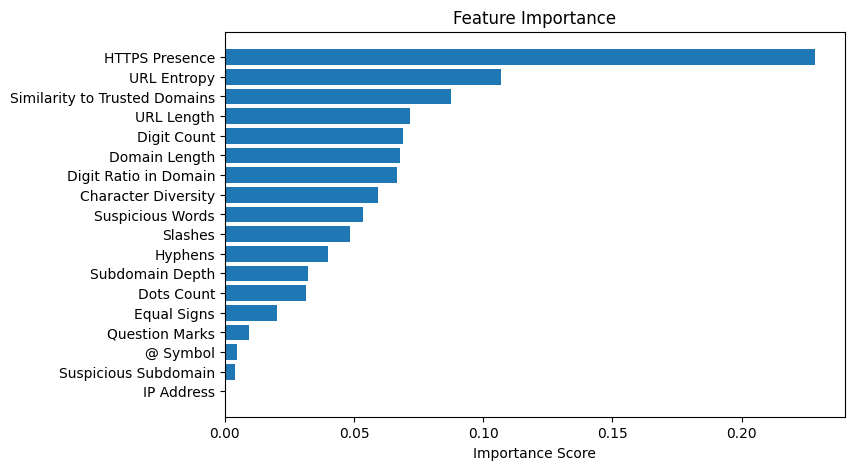

In [297]:
import numpy as np

importances = model.feature_importances_

feature_names = [
    "URL Length",
    "HTTPS Presence",
    "Dots Count",
    "Hyphens",
    "@ Symbol",
    "Slashes",
    "Question Marks",
    "Equal Signs",
    "Digit Count",
    "IP Address",
    "Suspicious Words",
    "Domain Length",
    "Digit Ratio in Domain",
    "Similarity to Trusted Domains",
    "URL Entropy",
    "Character Diversity",
    "Subdomain Depth",
    "Suspicious Subdomain"
]

# Sort features by importance
indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.title("Feature Importance")

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel("Importance Score")
plt.show()

In [298]:
# Accuracy
accuracy = accuracy_score(y_test, predictions)

print(f"\nAccuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))




Accuracy: 90.68%

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3720
           1       0.93      0.88      0.90      3553

    accuracy                           0.91      7273
   macro avg       0.91      0.91      0.91      7273
weighted avg       0.91      0.91      0.91      7273



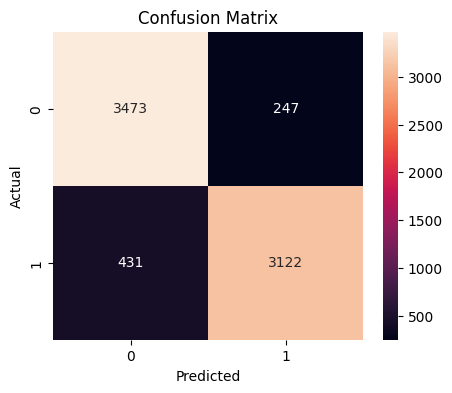

In [299]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [300]:
# Save model
joblib.dump(model, "phishing_model_RF.pkl")

print("\nModel saved successfully.")


Model saved successfully.
